# Finite-Size Spectra and Bulk–Edge Correspondence

Three analyses:
1. Bloch band structure (complex eigenvalues vs. $k$)
2. OBC finite-chain spectrum coloured by edge weight
3. Finite-size convergence of LDOS enhancement and band gap


In [1]:
import sys
sys.path.insert(0, "..")   # find src/nh_topo from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo.config import load_all, get_physics_params, get_figure_dir
from pathlib import Path

cfg = load_all(config_dir="../config")
p   = get_physics_params(cfg)

# Quick confirmation
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}")
print(f"Topological: t2/t1 = {p['t2']/p['t1']:.2f} > 1 → |nu|={nt.topological_invariant(p['t1'], p['t2'])}")


t1=0.8, t2=1.2, gamma=0.3, N=20
Topological: t2/t1 = 1.50 > 1 → |nu|=1


In [2]:
# Bloch bands
k_vals, bands = nt.compute_bloch_bands(p['t1'], p['t2'], p['gamma'])
gap_hw = p['gap_hw']

# OBC spectrum
H        = nt.build_ssh(p['N'], p['t1'], p['t2'], p['gamma'])
evals, evecs = nt.diagonalize(H)
left_w, _    = nt.edge_localization_weights(evecs)

# Finite-size convergence
oms_gap  = np.linspace(-gap_hw, gap_hw, 80)
xi       = nt.localization_length(p['t1'], p['t2'])
fs_data  = nt.finite_size_convergence(
    p['t1'], p['t2'], p['gamma'], p['N_vals_fs'], oms_gap, p['eta'])
print(f"Localization length xi = {xi:.3f} unit cells")
print(f"Enhancement values: {dict(zip(p['N_vals_fs'], [round(e,2) for e in fs_data['enhancement']]))}")


Localization length xi = 2.466 unit cells
Enhancement values: {5: 16.9, 8: 9.43, 10: 10.49, 15: 65.66, 20: 11.25, 30: 11.25, 40: 11.25}


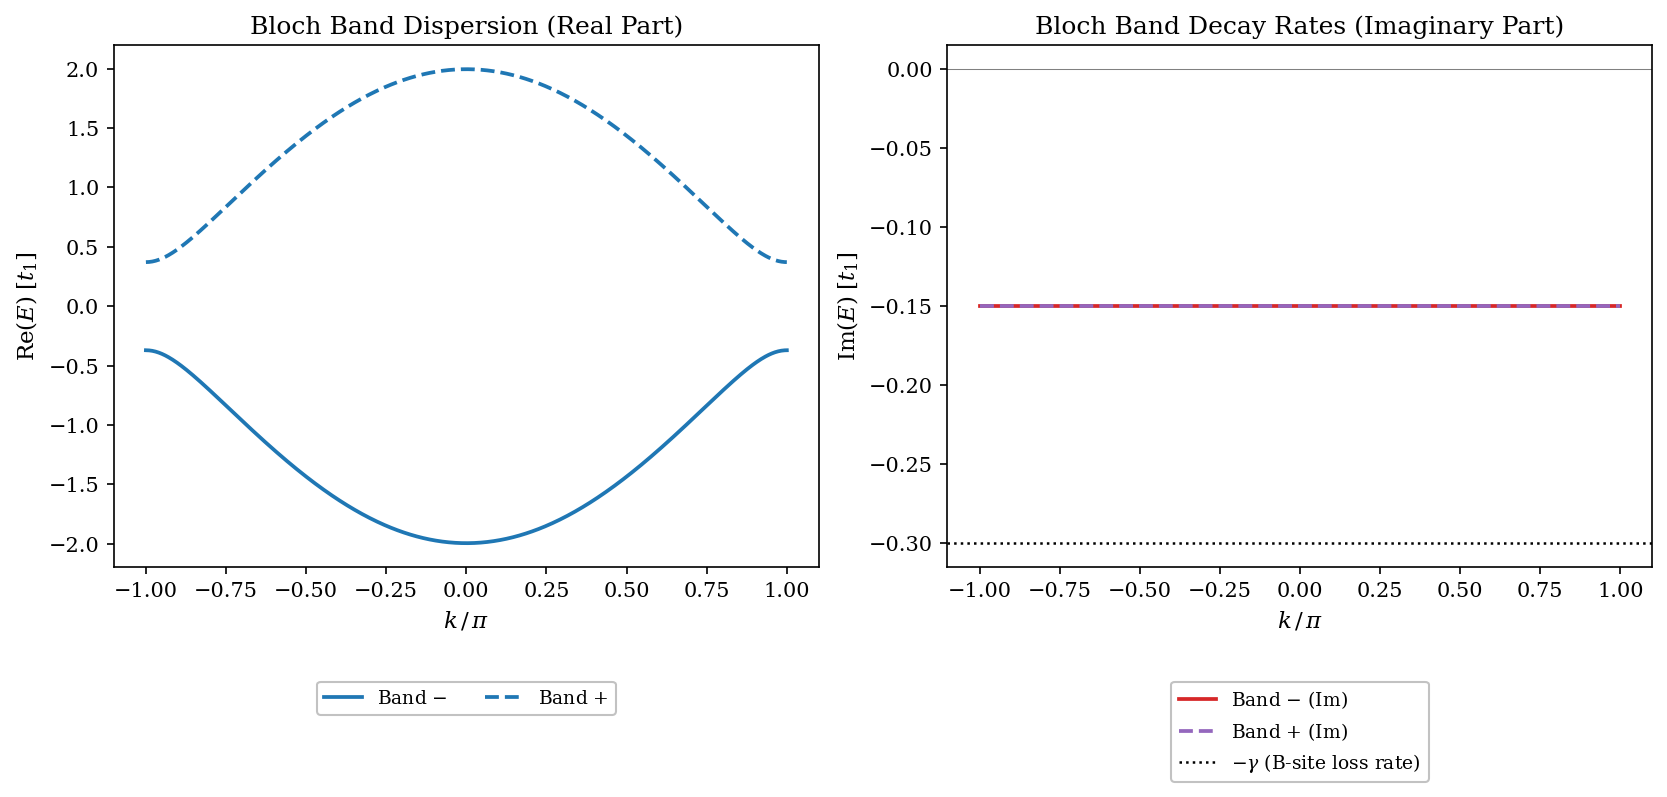

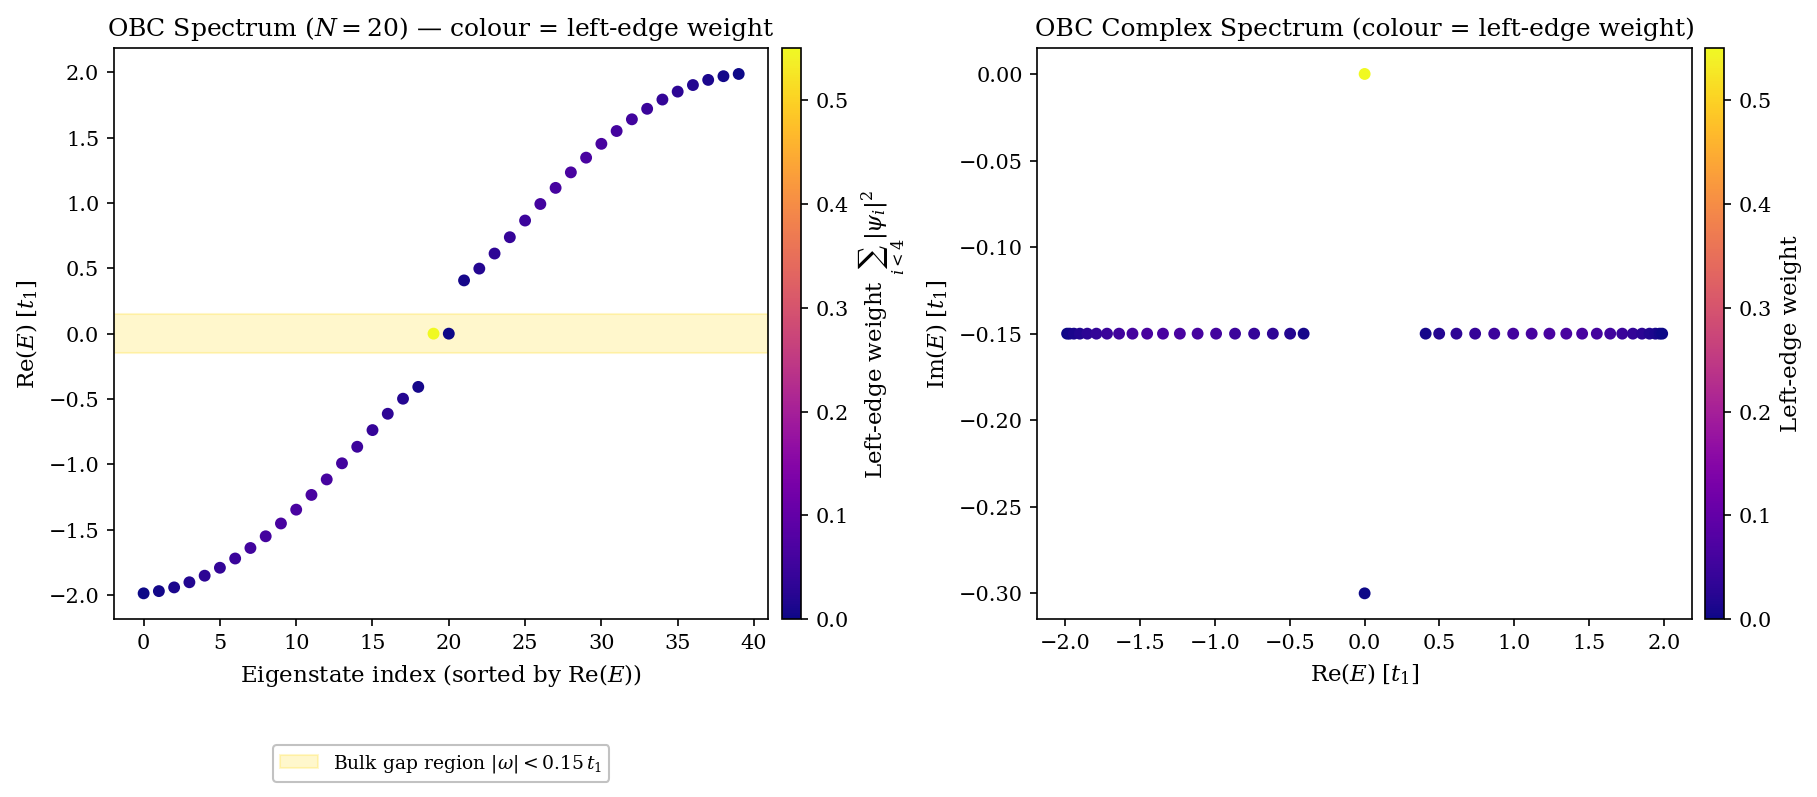

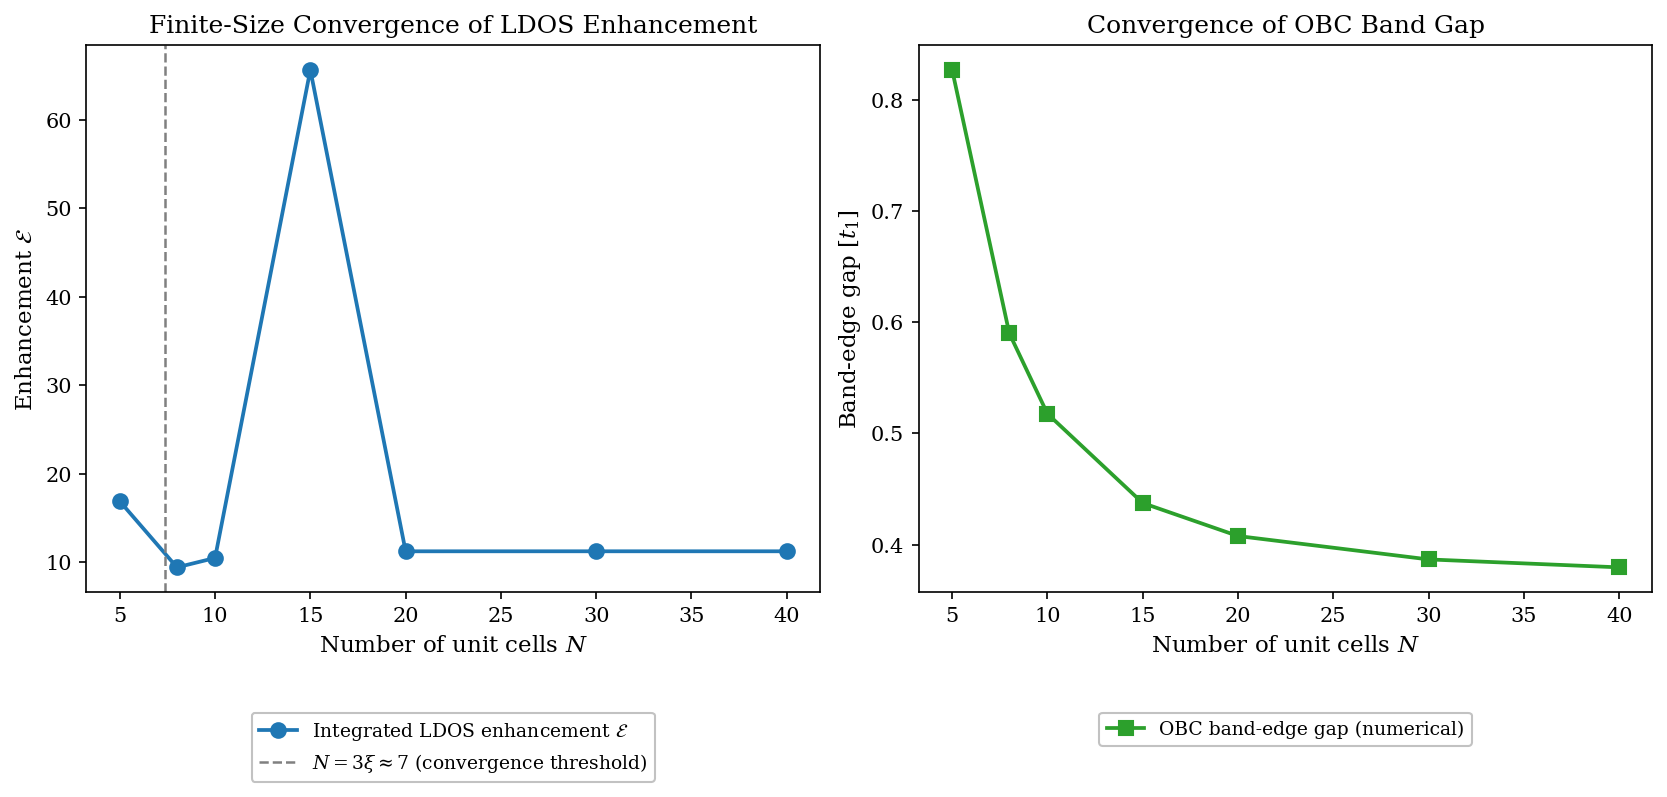

In [3]:
fig, axes = nt.plotting.plot_bloch_bands(k_vals, bands, p['gamma'])
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '03_numerical_bandstructures'), "01_bloch_bands")
plt.show()

fig, axes = nt.plotting.plot_obc_spectrum(evals, left_w, p['N'], gap_hw)
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '03_numerical_bandstructures'), "02_obc_spectrum")
plt.show()

fig, axes = nt.plotting.plot_finite_size_convergence(
    fs_data['N_vals'], fs_data['enhancement'], fs_data['gap_obc'], xi)
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '03_numerical_bandstructures'), "03_finite_size")
plt.show()
